# Combining multiple files
A very common obstacle to data analysis is when our data are spread out over multiple files. In the real world we often have
to bring data together from multiple sources before we can start our analysis.

## Concatenation
How do we combine multiple dataframes? One way is to concatenate which combines multiple dataframes together by appending it to the end of another dataframe.
Let's look at the dataframe that contains the monthly rainfall data for London, Berlin, and Edinburgh.

In [28]:
import pandas as pd
london_data="https://raw.githubusercontent.com/csbfx/advpy122-data/master/London_daily_rain.csv"

berlin_data="https://raw.githubusercontent.com/csbfx/advpy122-data/master/Berlin_daily_rain.csv"

edinburgh_data="https://raw.githubusercontent.com/csbfx/advpy122-data/master/Edinburgh_daily_rain.csv"

london_rain = pd.read_csv(london_data)
# london_rain.head()
# #london_rain.info()

In [29]:
berlin_rain = pd.read_csv(berlin_data)
# berlin_rain.head()

In [30]:
edinburgh_rain = pd.read_csv(edinburgh_data)
# edinburgh_rain.head()

Once we’ve got our three dataframes in memory, we can check that they have the same length and having the same columns:

In [4]:
# check the length of each dataframe
all_dfs = [london_rain, berlin_rain, edinburgh_rain]
print("Lengths:", [len(df) for df in all_dfs])

# check the columns of each dataframe
for cols in [df.columns for df in all_dfs]:
    print(cols)

Lengths: [21762, 21762, 21762]
Index(['Year', 'Month', 'Day of month', 'Day of year', 'Rainfall (mm)'], dtype='object')
Index(['Year', 'Month', 'Day of month', 'Day of year', 'Rainfall (mm)'], dtype='object')
Index(['Year', 'Month', 'Day of month', 'Day of year', 'Rainfall (mm)'], dtype='object')


Once we are satisfied that the columns are all the same, we know that we can combine these dataframes by simply putting them underneath each other to get one combined dataframe. The function that does the **concatenation** is `pd.concat`, and all we have to give it is a list of dataframes to concatenate:

In [5]:
all_rain = pd.concat(all_dfs)
all_rain

,Year,Month,Day of month,Day of year,Rainfall (mm)
0,1960,January,1,1,22.0
1,1960,January,2,2,23.0
2,1960,January,3,3,7.0
3,1960,January,4,4,0.0
4,1960,January,5,5,0.0
...,...,...,...,...,...
21757,2019,July,27,208,18.0
21758,2019,July,28,209,0.0
21759,2019,July,29,210,4.0
21760,2019,July,30,211,41.0


Although the data look fine from a glance at the big dataframe, in fact we have run into a common problem - we
have lost track of which rows belong to which city. In other words, if we take our big dataframe and select a single
day:

In [6]:
all_rain[(all_rain["Year"] == 2015)
        & (all_rain["Month"] == "October")
        & (all_rain["Day of month"]== 29)
        ]

,Year,Month,Day of month,Day of year,Rainfall (mm)
20390,2015,October,29,302,70.0
20390,2015,October,29,302,0.0
20390,2015,October,29,302,71.0


We can see that we have three rainfall measurements, but no idea which city they belong to. To fix this, we need to add a city column to each individual dataframe before we concatenate them.

In [7]:
london_rain["City"] = "London"
london_rain

,Year,Month,Day of month,Day of year,Rainfall (mm),City
0,1960,January,1,1,22.0,London
1,1960,January,2,2,23.0,London
2,1960,January,3,3,7.0,London
3,1960,January,4,4,0.0,London
4,1960,January,5,5,0.0,London
...,...,...,...,...,...,...
21757,2019,July,27,208,20.0,London
21758,2019,July,28,209,0.0,London
21759,2019,July,29,210,0.0,London
21760,2019,July,30,211,42.0,London


In [8]:
london_rain["City"] = "London"
berlin_rain["City"] = "Berlin"
edinburgh_rain["City"] = "Edinburgh"

all_rain = pd.concat(all_dfs)
all_rain

,Year,Month,Day of month,Day of year,Rainfall (mm),City
0,1960,January,1,1,22.0,London
1,1960,January,2,2,23.0,London
2,1960,January,3,3,7.0,London
3,1960,January,4,4,0.0,London
4,1960,January,5,5,0.0,London
...,...,...,...,...,...,...
21757,2019,July,27,208,18.0,Edinburgh
21758,2019,July,28,209,0.0,Edinburgh
21759,2019,July,29,210,4.0,Edinburgh
21760,2019,July,30,211,41.0,Edinburgh


In [9]:
all_rain[(all_rain["Year"] == 2015)
        & (all_rain["Month"] == "October")
        & (all_rain["Day of month"]== 29)
        ]

,Year,Month,Day of month,Day of year,Rainfall (mm),City
20390,2015,October,29,302,70.0,London
20390,2015,October,29,302,0.0,Berlin
20390,2015,October,29,302,71.0,Edinburgh


In [10]:
## Make a plot with the combined dataframe
from pandas.api.types import CategoricalDtype
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

months=["January","February","March","April","May","June","July","August",
"September","October","November","December"]

all_rain["Month"] = all_rain["Month"].astype(
    CategoricalDtype(categories=months, ordered=True)
)

all_rain.head()

,Year,Month,Day of month,Day of year,Rainfall (mm),City
0,1960,January,1,1,22.0,London
1,1960,January,2,2,23.0,London
2,1960,January,3,3,7.0,London
3,1960,January,4,4,0.0,London
4,1960,January,5,5,0.0,London


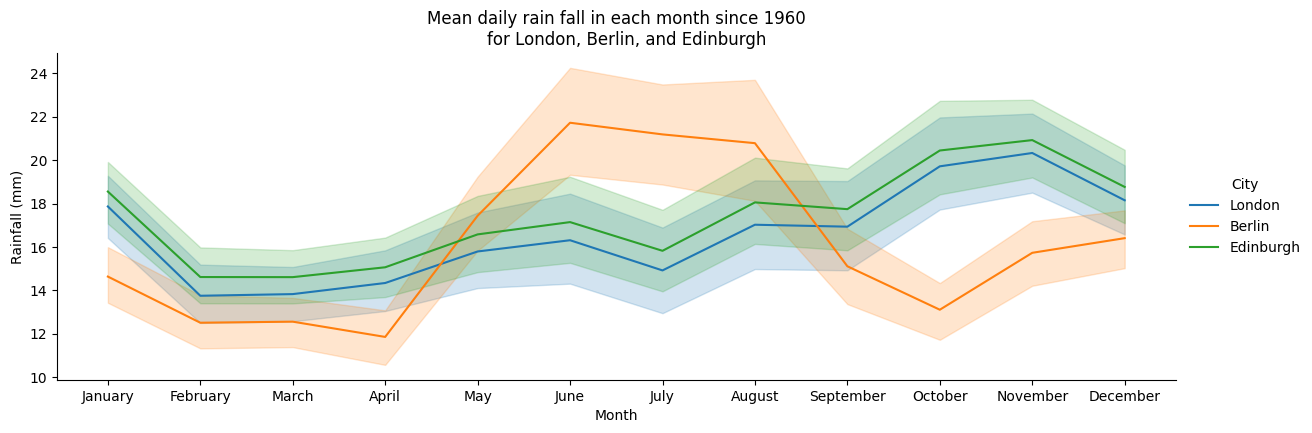

In [11]:
all_rain.reset_index(inplace=True)
sns.relplot(
    data=all_rain,
    x="Month",
    y="Rainfall (mm)",
    aspect=3,
    height=4,
    hue="City",
    kind="line"
)
plt.title("""Mean daily rain fall in each month since 1960
    for London, Berlin, and Edinburgh""");


Berlin is wettest in the summer, with very dry months at the start of the year, whereas the two cities in the UK
have a longer wet period stretching late into the winter.

### 2.2 Adding a single column
To really examine patterns of weather, it would be convenient to have the temperature and rainfall in a single dataframe. Let’s read in our temperature data from _weather.csv_ and see how we might proceed:

In [12]:
import pandas as pd
weather_data = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/weather.csv"
weather = pd.read_csv(weather_data)
weather

,City,Year,Month,Day of year,Day of month,Mean temperature
0,Berlin,1960,January,1,1,6.4
1,Berlin,1960,January,2,2,8.1
2,Berlin,1960,January,3,3,5.4
3,Berlin,1960,January,4,4,3.9
4,Berlin,1960,January,5,5,6.0
...,...,...,...,...,...,...
63711,London,2018,October,300,27,4.9
63712,London,2018,October,301,28,7.4
63713,London,2018,October,302,29,5.8
63714,London,2018,October,303,30,6.6


In [13]:
weather.City.unique()

array(['Berlin', 'Edinburgh', 'London'], dtype=object)

Here we have an example of a problem that commonly occurs in real life: our two datasets have almost - but not exactly - the same number of rows. In this case, it’s because the temperature data stops in October 2018, but the rainfall data stops in July 2019. In real world data there can be any number of reasons for slight discrepancies between two datasets.

Because the rows don’t match exactly, we **can’t** combine the two datasets using **concatenation**. What we want is to add just a single column from the temperature dataset to our rainfall `all_rain` dataset. The best way to do this is to set the _same index_ on both the big dataframe and the new column that we want to add.

In [14]:
# set temperature index
temperatures = (
    weather.set_index(["City", "Year", "Day of year"])
    ["Mean temperature"]
)
temperatures

City    Year  Day of year
Berlin  1960  1              6.4
              2              8.1
              3              5.4
              4              3.9
              5              6.0
                            ... 
London  2018  300            4.9
              301            7.4
              302            5.8
              303            6.6
              304            7.0
Name: Mean temperature, Length: 63716, dtype: float64

In [15]:
# set the same index for all_rain
all_rain = all_rain.set_index(["City", "Year", "Day of year"])
all_rain

index    Month  Day of month  Rainfall (mm)
City      Year Day of year                                             
London    1960 1                0  January             1           22.0
               2                1  January             2           23.0
               3                2  January             3            7.0
               4                3  January             4            0.0
               5                4  January             5            0.0
...                           ...      ...           ...            ...
Edinburgh 2019 208          21757     July            27           18.0
               209          21758     July            28            0.0
               210          21759     July            29            4.0
               211          21760     July            30           41.0
               212          21761     July            31            0.0

[65286 rows x 4 columns]

We have a series and a dataframe that have the same indices. The indices don’t have exactly the same values - we can tell this because the lengths of the series and the dataframe are different (63716 vs 65286 rows), or we can check it:

In [16]:
temperatures.index.equals(all_rain.index)

False

To add the temperature to our big dataframe, all we have to do is assign a new column like normal.

In [17]:
all_rain["Temperature (°C)"] = temperatures
all_rain

index    Month  Day of month  Rainfall (mm)  \
City      Year Day of year                                                
London    1960 1                0  January             1           22.0   
               2                1  January             2           23.0   
               3                2  January             3            7.0   
               4                3  January             4            0.0   
               5                4  January             5            0.0   
...                           ...      ...           ...            ...   
Edinburgh 2019 208          21757     July            27           18.0   
               209          21758     July            28            0.0   
               210          21759     July            29            4.0   
               211          21760     July            30           41.0   
               212          21761     July            31            0.0   

                            Temperature (°C)  
City      Year Day of year                    
London    1960 1                        10.6  
               2                         6.1  
               3                         8.4  
               4                         9.4  
               5                         8.9  
...                                      ...  
Edinburgh 2019 208                       NaN  
               209                       NaN  
               210                       NaN  
               211                       NaN  
               212                       NaN  

[65286 rows x 5 columns]

Pandas uses the matching indices to insert the temperature into the correct rows, and automatically filled in missing data for the rows where there weren’t matching temperature values.

In [18]:
all_rain.reset_index(inplace=True)
all_rain

,City,Year,Day of year,index,Month,Day of month,Rainfall (mm),Temperature (°C)
0,London,1960,1,0,January,1,22.0,10.6
1,London,1960,2,1,January,2,23.0,6.1
2,London,1960,3,2,January,3,7.0,8.4
3,London,1960,4,3,January,4,0.0,9.4
4,London,1960,5,4,January,5,0.0,8.9
...,...,...,...,...,...,...,...,...
65281,Edinburgh,2019,208,21757,July,27,18.0,NaN
65282,Edinburgh,2019,209,21758,July,28,0.0,NaN
65283,Edinburgh,2019,210,21759,July,29,4.0,NaN
65284,Edinburgh,2019,211,21760,July,30,41.0,NaN


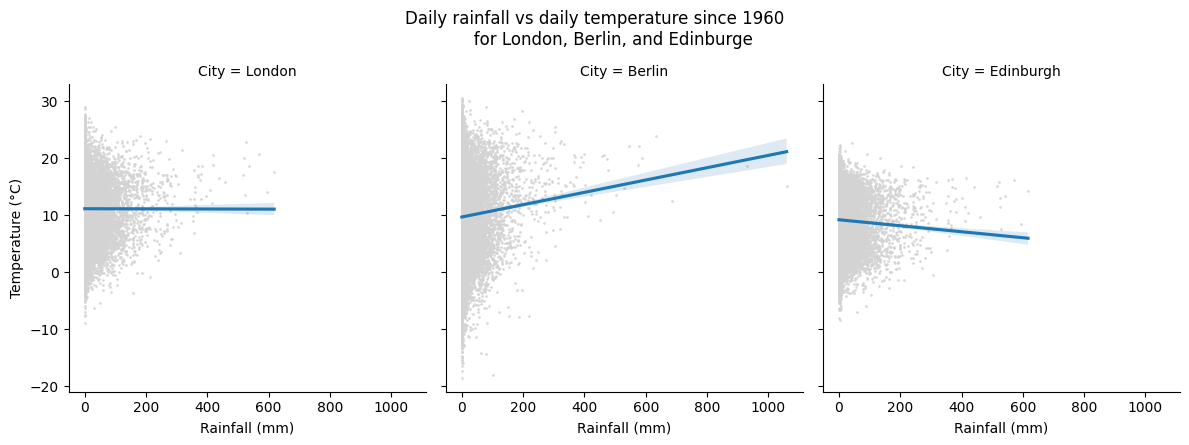

In [19]:
## Create a correlation plot `lmplot` to see if there is any correlation
## between rainfall and temperature
import seaborn as sns
g=sns.lmplot(
    data=all_rain,
    col="City",
    x="Rainfall (mm)",
    y="Temperature (°C)",
    scatter_kws={"s":1,"color":"lightgrey"},
    height=4,
)
g.fig.suptitle(
    """Daily rainfall vs daily temperature since 1960
       for London, Berlin, and Edinburge""",y=1.1
);

It appears not for the two British cities, but in Berlin, hotter days are definitely wetter.

### Merging to combine two dataframe
If we have a situation that’s more complicated than either of the two outlined above, then we need a **merge**.

Unlike concatenating or adding single columns, merging allows us to combine two entire dataframes while having much more control over the process. For example, we can specify exactly how to find matching rows, what we want to do when there are missing rows, and what we want to do when there are multiple matching rows.

Let's use the eukaryote dataset and a file with the common names for the organisms:

In [20]:
import pandas as pd

common_name_data = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/common_names.csv"
euk_data = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/euk.tsv"

euk = pd.read_csv(euk_data, sep="\t")
names = pd.read_csv(common_name_data)

euk

,Species,Kingdom,Class,Size (Mb),GC%,Number of genes,Number of proteins,Publication year,Assembly status
0,Emiliania huxleyi CCMP1516,Protists,Other Protists,167.676000,64.5,38549,38554,2013,Scaffold
1,Arabidopsis thaliana,Plants,Land Plants,119.669000,36.0529,38311,48265,2001,Chromosome
2,Glycine max,Plants,Land Plants,979.046000,35.1153,59847,71219,2010,Chromosome
3,Medicago truncatula,Plants,Land Plants,412.924000,34.047,37603,41939,2011,Chromosome
4,Solanum lycopersicum,Plants,Land Plants,828.349000,35.6991,31200,37660,2010,Chromosome
...,...,...,...,...,...,...,...,...,...
8297,Saccharomyces cerevisiae,Fungi,Ascomycetes,3.993920,38.2,-,-,2017,Scaffold
8298,Saccharomyces cerevisiae,Fungi,Ascomycetes,0.586761,38.5921,155,298,1992,Chromosome
8299,Saccharomyces cerevisiae,Fungi,Ascomycetes,12.020400,38.2971,-,-,2018,Chromosome
8300,Saccharomyces cerevisiae,Fungi,Ascomycetes,11.960900,38.2413,-,-,2018,Chromosome


In [21]:
names

,scientific name,common name
0,Simonsiella muelleri,Scheibenbakterien
1,Simonsiella muelleri,Scheibenbakterien Muller 1911
2,Escherichia coli,E. coli
3,Rickettsia akari,rickettsialpox
4,Anaplasma phagocytophilum,agent of human granulocytic ehrlichiosis
...,...,...
14436,Riboviria,RNA viruses and viroids
14437,Neoheterocotyle quadrispinata,Yotsu-toge-iban-chu
14438,Arthroleptis lameerei,Lameere's squeaker
14439,Erebia albergana,almond-eyed ringlet butterfly


Our goal is to add a new column to our eukaryote dataframe that contains the common name.

Here is the challenge, each **Species** in the `euk` dataframe can have zero, one, or multiple **common names**, and a
**common name** from the `names` dataframe can belong to zero, one or multiple **Species**. This is where most of the
complication lies in merging: deciding what to do when we have multiple matches and missing data.

The method that we need is `merge`. We will have to tell pandas explicitly which columns we want to match. To do this, we refer to the dataframe on which we called the method (df) as the right dataframe, and the one that we passed as the argument (names) as the left dataframe. These are conventional names, simply based
on the order in which we write the variables. So, for our dataset, the **Species** column in the left dataframe matches
the scientific name column from the right dataframe:

In [22]:
merged = euk.merge(names, left_on="Species", right_on="scientific name")
merged

,Species,Kingdom,Class,Size (Mb),GC%,Number of genes,Number of proteins,Publication year,Assembly status,scientific name,common name
0,Arabidopsis thaliana,Plants,Land Plants,119.6690,36.0529,38311,48265,2001,Chromosome,Arabidopsis thaliana,mouse-ear cress
1,Arabidopsis thaliana,Plants,Land Plants,119.6690,36.0529,38311,48265,2001,Chromosome,Arabidopsis thaliana,thale-cress
2,Glycine max,Plants,Land Plants,979.0460,35.1153,59847,71219,2010,Chromosome,Glycine max,soybeans
3,Hordeum vulgare,Plants,Land Plants,4006.1200,44.3,-,-,2019,Scaffold,Hordeum vulgare,barley
4,Oryza sativa Japonica Group,Plants,Land Plants,374.4230,43.5769,35219,42580,2015,Chromosome,Oryza sativa Japonica Group,Japonica rice
...,...,...,...,...,...,...,...,...,...,...,...
3337,Saccharomyces cerevisiae,Fungi,Ascomycetes,12.0204,38.2971,-,-,2018,Chromosome,Saccharomyces cerevisiae,brewer's yeast
3338,Saccharomyces cerevisiae,Fungi,Ascomycetes,11.9609,38.2413,-,-,2018,Chromosome,Saccharomyces cerevisiae,S. cerevisiae
3339,Saccharomyces cerevisiae,Fungi,Ascomycetes,11.9609,38.2413,-,-,2018,Chromosome,Saccharomyces cerevisiae,brewer's yeast
3340,Saccharomyces cerevisiae,Fungi,Ascomycetes,11.8207,38.2536,-,-,2018,Chromosome,Saccharomyces cerevisiae,S. cerevisiae


we can see another interesting phenomenon: where a species has multiple common names, we have ended up with multiple copies of each original row. For example, Arabidopsis thaliana has two common names:

In [23]:
 names[names["scientific name"]== "Arabidopsis thaliana"]

,scientific name,common name
249,Arabidopsis thaliana,mouse-ear cress
250,Arabidopsis thaliana,thale-cress


so every Arabidopsis thaliana genome in the original dataframe appears twice in the merged dataframe, once with
each common name.

Understanding this behavior is very important, so let’s summarize:
- genomes that have no matching common name are missing from the merged dataframe
- genomes that have multiple common names are duplicated in the merged dataframe

The easiest way to avoid having duplicated entries is to make sure that our names dataframe only contains a single common name for each scientific name, which we can do by calling `drop_duplicates` and telling pandas which columns we want to avoid duplicates in:

In [24]:
names.drop_duplicates(subset=["scientific name"])

,scientific name,common name
0,Simonsiella muelleri,Scheibenbakterien
2,Escherichia coli,E. coli
3,Rickettsia akari,rickettsialpox
4,Anaplasma phagocytophilum,agent of human granulocytic ehrlichiosis
5,Neorickettsia risticii,equine monocytic ehrlichiosis agent
...,...,...
14435,Riboviria,RNA viruses
14437,Neoheterocotyle quadrispinata,Yotsu-toge-iban-chu
14438,Arthroleptis lameerei,Lameere's squeaker
14439,Erebia albergana,almond-eyed ringlet butterfly


In [25]:
# Let's do the merge again with unique common names
merged = euk.merge(names.drop_duplicates(subset=["scientific name"]),
                   left_on="Species",
                   right_on="scientific name")
merged

,Species,Kingdom,Class,Size (Mb),GC%,Number of genes,Number of proteins,Publication year,Assembly status,scientific name,common name
0,Arabidopsis thaliana,Plants,Land Plants,119.669000,36.0529,38311,48265,2001,Chromosome,Arabidopsis thaliana,mouse-ear cress
1,Glycine max,Plants,Land Plants,979.046000,35.1153,59847,71219,2010,Chromosome,Glycine max,soybeans
2,Hordeum vulgare,Plants,Land Plants,4006.120000,44.3,-,-,2019,Scaffold,Hordeum vulgare,barley
3,Oryza sativa Japonica Group,Plants,Land Plants,374.423000,43.5769,35219,42580,2015,Chromosome,Oryza sativa Japonica Group,Japonica rice
4,Triticum aestivum,Plants,Land Plants,14547.300000,46.0544,-,-,2018,Chromosome,Triticum aestivum,Canadian hard winter wheat
...,...,...,...,...,...,...,...,...,...,...,...
1993,Saccharomyces cerevisiae,Fungi,Ascomycetes,3.993920,38.2,-,-,2017,Scaffold,Saccharomyces cerevisiae,S. cerevisiae
1994,Saccharomyces cerevisiae,Fungi,Ascomycetes,0.586761,38.5921,155,298,1992,Chromosome,Saccharomyces cerevisiae,S. cerevisiae
1995,Saccharomyces cerevisiae,Fungi,Ascomycetes,12.020400,38.2971,-,-,2018,Chromosome,Saccharomyces cerevisiae,S. cerevisiae
1996,Saccharomyces cerevisiae,Fungi,Ascomycetes,11.960900,38.2413,-,-,2018,Chromosome,Saccharomyces cerevisiae,S. cerevisiae


We get a single output row for each Species that has a common name. The species that don't have a common name are now missing in the merged dataframe.

To put back the missing species - the ones that don’t have matching common names - we need to take a look at the `how` argument to merge. The merges that we have been doing so far have been using the default option, which is 'inner':

In [26]:
merged = euk.merge(names.drop_duplicates(subset=["scientific name"]),
                   left_on="Species",
                   right_on="scientific name",
                   how="inner")
merged

,Species,Kingdom,Class,Size (Mb),GC%,Number of genes,Number of proteins,Publication year,Assembly status,scientific name,common name
0,Arabidopsis thaliana,Plants,Land Plants,119.669000,36.0529,38311,48265,2001,Chromosome,Arabidopsis thaliana,mouse-ear cress
1,Glycine max,Plants,Land Plants,979.046000,35.1153,59847,71219,2010,Chromosome,Glycine max,soybeans
2,Hordeum vulgare,Plants,Land Plants,4006.120000,44.3,-,-,2019,Scaffold,Hordeum vulgare,barley
3,Oryza sativa Japonica Group,Plants,Land Plants,374.423000,43.5769,35219,42580,2015,Chromosome,Oryza sativa Japonica Group,Japonica rice
4,Triticum aestivum,Plants,Land Plants,14547.300000,46.0544,-,-,2018,Chromosome,Triticum aestivum,Canadian hard winter wheat
...,...,...,...,...,...,...,...,...,...,...,...
1993,Saccharomyces cerevisiae,Fungi,Ascomycetes,3.993920,38.2,-,-,2017,Scaffold,Saccharomyces cerevisiae,S. cerevisiae
1994,Saccharomyces cerevisiae,Fungi,Ascomycetes,0.586761,38.5921,155,298,1992,Chromosome,Saccharomyces cerevisiae,S. cerevisiae
1995,Saccharomyces cerevisiae,Fungi,Ascomycetes,12.020400,38.2971,-,-,2018,Chromosome,Saccharomyces cerevisiae,S. cerevisiae
1996,Saccharomyces cerevisiae,Fungi,Ascomycetes,11.960900,38.2413,-,-,2018,Chromosome,Saccharomyces cerevisiae,S. cerevisiae


`how='inner'` means that we want to keep only the rows that are present in both of the input dataframes. Changing this to `how='left'` means that we want to include all the rows from the left dataframe, even the ones that have no matching row in the right. In our case, this means keeping all species, even the ones that have no common name:

In [27]:
merged = euk.merge(names.drop_duplicates(subset=["scientific name"]),
                   left_on="Species",
                   right_on="scientific name",
                   how="left")
merged

,Species,Kingdom,Class,Size (Mb),GC%,Number of genes,Number of proteins,Publication year,Assembly status,scientific name,common name
0,Emiliania huxleyi CCMP1516,Protists,Other Protists,167.676000,64.5,38549,38554,2013,Scaffold,NaN,NaN
1,Arabidopsis thaliana,Plants,Land Plants,119.669000,36.0529,38311,48265,2001,Chromosome,Arabidopsis thaliana,mouse-ear cress
2,Glycine max,Plants,Land Plants,979.046000,35.1153,59847,71219,2010,Chromosome,Glycine max,soybeans
3,Medicago truncatula,Plants,Land Plants,412.924000,34.047,37603,41939,2011,Chromosome,NaN,NaN
4,Solanum lycopersicum,Plants,Land Plants,828.349000,35.6991,31200,37660,2010,Chromosome,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
8297,Saccharomyces cerevisiae,Fungi,Ascomycetes,3.993920,38.2,-,-,2017,Scaffold,Saccharomyces cerevisiae,S. cerevisiae
8298,Saccharomyces cerevisiae,Fungi,Ascomycetes,0.586761,38.5921,155,298,1992,Chromosome,Saccharomyces cerevisiae,S. cerevisiae
8299,Saccharomyces cerevisiae,Fungi,Ascomycetes,12.020400,38.2971,-,-,2018,Chromosome,Saccharomyces cerevisiae,S. cerevisiae
8300,Saccharomyces cerevisiae,Fungi,Ascomycetes,11.960900,38.2413,-,-,2018,Chromosome,Saccharomyces cerevisiae,S. cerevisiae
